# 🌐 Functional Tests / End-to-End Testing
## Demo en Vivo + Ejercicio de Cierre (15 min)

**Curso:** Pruebas de Software · 7mo Semestre  
**Herramienta:** Python + Playwright  
**App objetivo:** [TodoMVC](https://demo.playwright.dev/todomvc) — app pública diseñada para practicar E2E  
**Valle del Software**

---

### ¿Qué vamos a hacer?

| Sección | Contenido | Tiempo |
|---------|-----------|--------|
| 🔧 Setup | Instalar Playwright en Colab | 3 min |
| 🎬 Demo 1 | Navegar, encontrar elementos, hacer assertions | 5 min |
| 🏗️ Demo 2 | Page Object Model (POM) | 5 min |
| 🎭 Demo 3 | Flujo completo: crear, completar, eliminar tarea | 5 min |
| 🎯 Ejercicio | Tu turno — 15 minutos | 15 min |

> 💡 En Colab corremos en modo **headless** (sin ventana visible). Capturas de pantalla automáticas muestran el resultado.

---
## ⚙️ Setup — Instalar Playwright

In [1]:
# Instalar Playwright y Chromium de forma portable (Windows/Linux/Colab)
import sys
import subprocess

%pip install -q playwright pytest-playwright
subprocess.run([sys.executable, "-m", "playwright", "install", "chromium"], check=True)

print('✅ Playwright instalado y listo.')


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
✅ Playwright instalado y listo.


In [2]:
# Imports y utilidad para mostrar screenshots en el notebook
from playwright.sync_api import sync_playwright, Page, expect
from IPython.display import Image, display
import threading
import asyncio
import warnings
import sys
import re

# URL de la app de practica (TodoMVC - Playwright oficial)
TODO_URL = 'https://demo.playwright.dev/todomvc'

def run_in_thread(fn, *args, **kwargs):
    """Ejecuta Playwright en un hilo separado para evitar conflicto con el loop de Jupyter."""
    result = {}
    error = {}

    def target():
        try:
            if sys.platform == 'win32' and hasattr(asyncio, 'WindowsProactorEventLoopPolicy'):
                with warnings.catch_warnings():
                    warnings.simplefilter('ignore', DeprecationWarning)
                    asyncio.set_event_loop_policy(asyncio.WindowsProactorEventLoopPolicy())
            result['value'] = fn(*args, **kwargs)
        except Exception as exc:
            error['value'] = exc

    thread = threading.Thread(target=target, daemon=False)
    thread.start()
    thread.join()

    if 'value' in error:
        raise error['value']
    return result.get('value')


def screenshot(page: Page, filename: str, title: str = ''):
    """Captura la pantalla y la muestra en el notebook."""
    path = f'/tmp/{filename}.png'
    page.screenshot(path=path, full_page=False)
    if title:
        print(f'📸 {title}')
    display(Image(path, width=700))

print('✅ Imports listos. App objetivo:', TODO_URL)

✅ Imports listos. App objetivo: https://demo.playwright.dev/todomvc


In [3]:
print('URL de la app objetivo:')
print(TODO_URL)

URL de la app objetivo:
https://demo.playwright.dev/todomvc


---
## 🎬 Demo 1 — Navegar, Localizar y Hacer Assertions

Los tres pilares de cualquier test E2E:
1. **Navegar** a una URL
2. **Localizar** un elemento (con locators robustos)
3. **Verificar** el comportamiento esperado

C:\Users\WinterOS\AppData\Local\Temp\ipykernel_21144\2512270375.py:20: DeprecationWarning: 'asyncio.WindowsProactorEventLoopPolicy' is deprecated and slated for removal in Python 3.16
  if sys.platform == 'win32' and hasattr(asyncio, 'WindowsProactorEventLoopPolicy'):


📸 ✅ App cargada correctamente


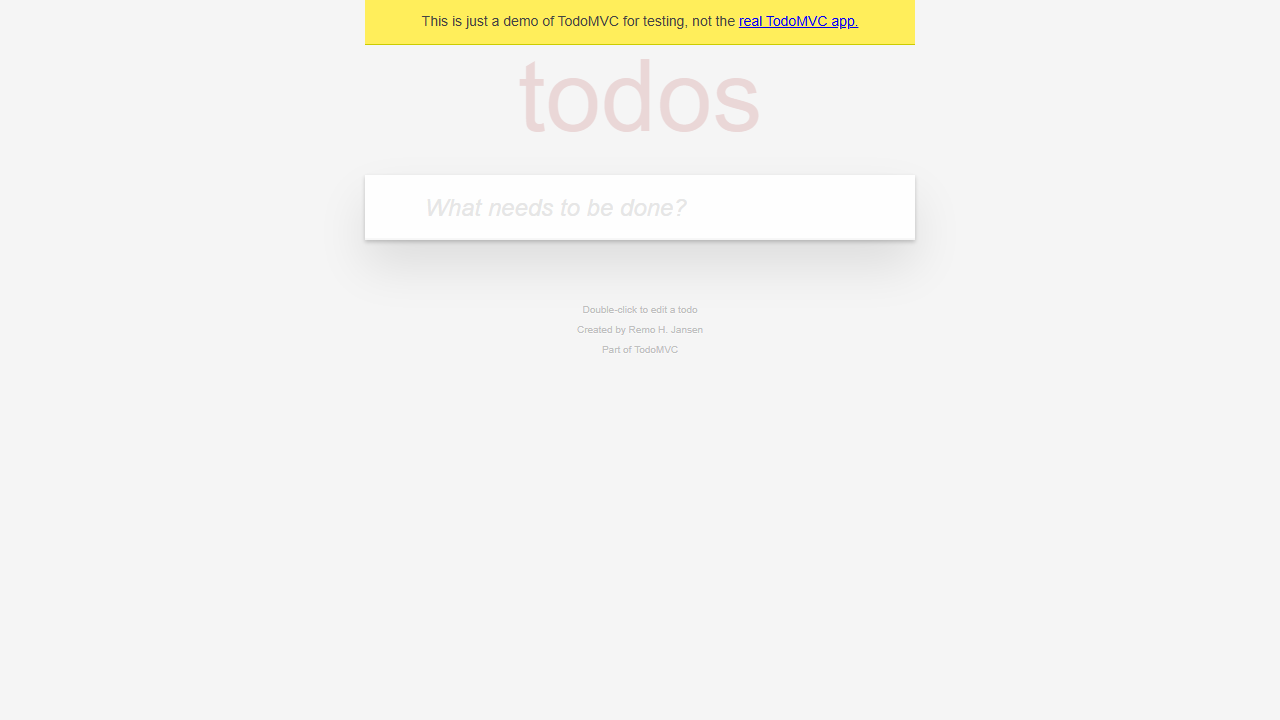

URL actual: https://demo.playwright.dev/todomvc/#/
Titulo:     React • TodoMVC


In [4]:
# -- Demo 1: Navegar y verificar que la app carga ------------

from playwright.sync_api import sync_playwright

def run_demo1():
    with sync_playwright() as pw:
        browser = pw.chromium.launch(headless=True)
        page = browser.new_page()

        # 1. NAVEGAR
        page.goto(TODO_URL)

        # 2. LOCALIZAR - por rol semantico (recomendado)
        titulo = page.get_by_role('heading', name='todos')
        input_nueva = page.get_by_placeholder('What needs to be done?')

        # 3. VERIFICAR con expect() - tiene auto-retry
        expect(titulo).to_be_visible()
        expect(input_nueva).to_be_visible()
        expect(input_nueva).to_be_enabled()

        # Tambien podemos verificar el titulo de la pagina
        expect(page).to_have_title(re.compile('TodoMVC', re.IGNORECASE))

        screenshot(page, 'demo1_carga', '✅ App cargada correctamente')
        print(f'URL actual: {page.url}')
        print(f'Titulo:     {page.title()}')

        browser.close()

run_in_thread(run_demo1)

### Tipos de locators — Orden de preferencia

```python
# ✅ MEJORES — semánticos y robustos
page.get_by_role('button', name='Guardar')     # Por rol ARIA
page.get_by_label('Correo electrónico')         # Por label de formulario
page.get_by_placeholder('¿Qué necesitas hacer?')
page.get_by_test_id('submit-btn')              # data-testid

# ⚠️ ACEPTABLES
page.get_by_text('Iniciar sesión')             # Texto visible
page.locator('#mi-id')                          # Por ID

# ❌ EVITAR — frágiles
page.locator('.btn-submit-v2-active')           # CSS específico
page.locator('/html/body/div[2]/button')        # XPath absoluto
```

---
## 🎬 Demo 2 — Interacción: Crear y Verificar Tareas

C:\Users\WinterOS\AppData\Local\Temp\ipykernel_21144\2512270375.py:20: DeprecationWarning: 'asyncio.WindowsProactorEventLoopPolicy' is deprecated and slated for removal in Python 3.16
  if sys.platform == 'win32' and hasattr(asyncio, 'WindowsProactorEventLoopPolicy'):


📸 ✅ 3 tareas creadas correctamente


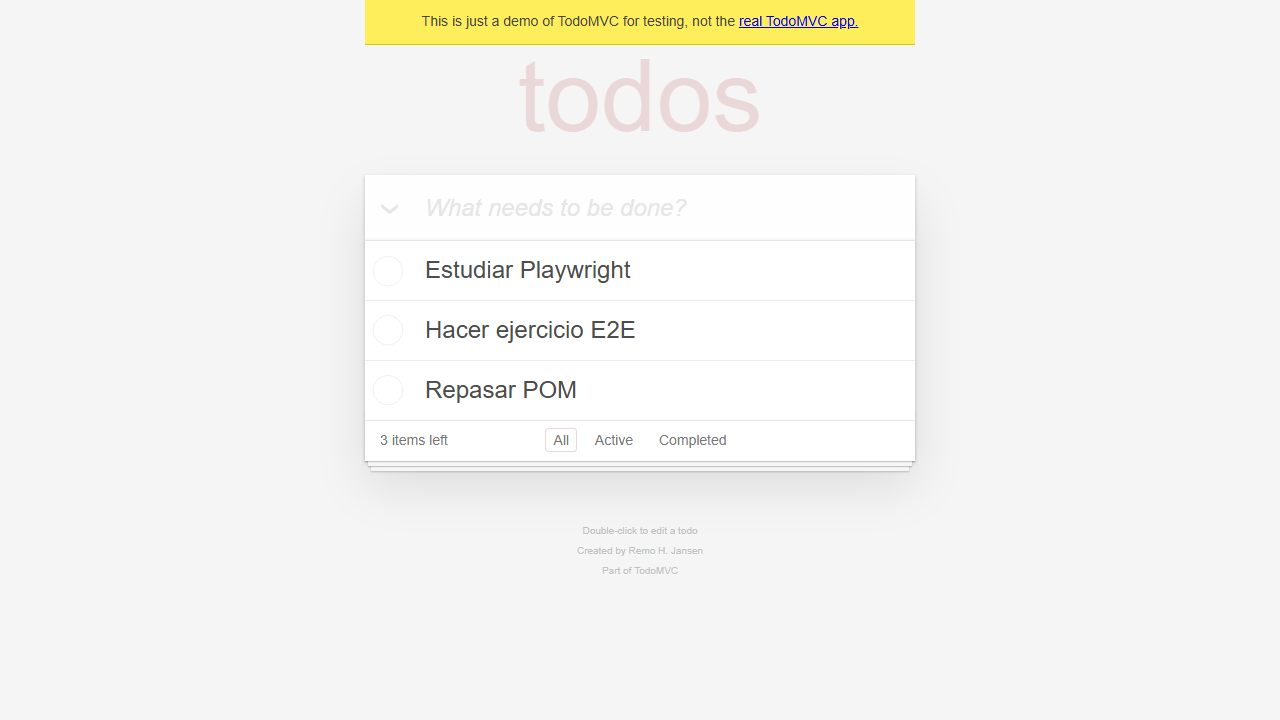

Tareas en pantalla: 3
📸 ✅ Primera tarea completada


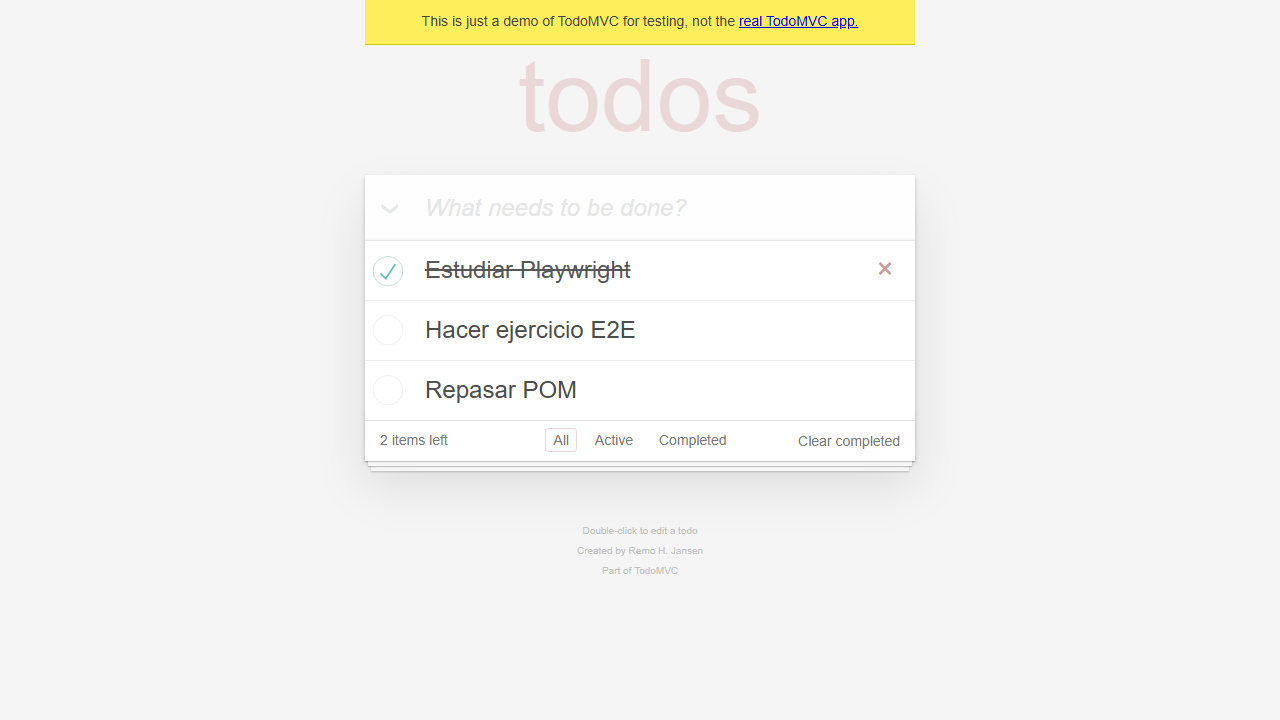

📸 ✅ Filtro "Active" - solo 2 tareas visibles


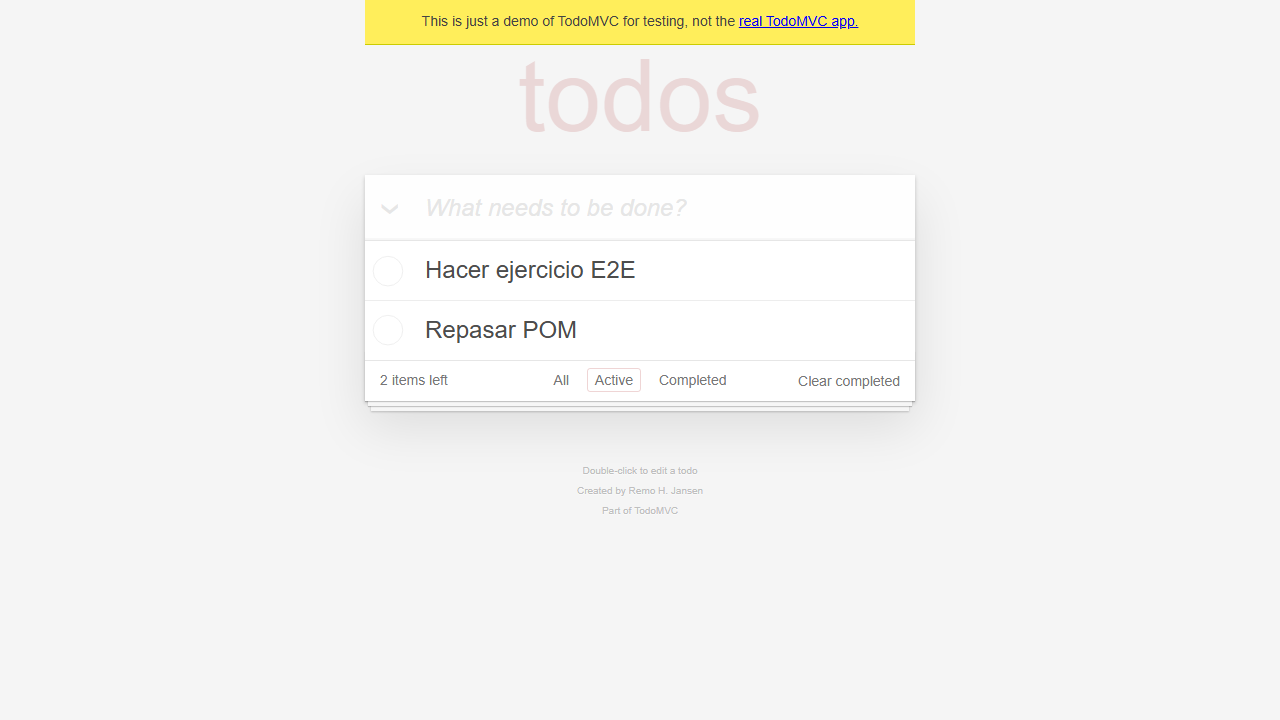


✅ Demo 2 completada - interaccion verificada


In [5]:
# -- Demo 2: Crear tareas e interactuar con la UI ------------

from playwright.sync_api import sync_playwright, expect

def run_demo2():
    with sync_playwright() as pw:
        browser = pw.chromium.launch(headless=True)
        page = browser.new_page()

        # Asegurar un estado limpio: limpiar localStorage y recargar la pagina
        page.goto(TODO_URL)
        page.evaluate("localStorage.clear();")
        page.reload()

        input_nueva = page.get_by_placeholder('What needs to be done?')

        # -- CREAR 3 TAREAS ----------------------------------
        tareas = ['Estudiar Playwright', 'Hacer ejercicio E2E', 'Repasar POM']

        for tarea in tareas:
            input_nueva.fill(tarea)
            input_nueva.press('Enter')

        # -- VERIFICAR QUE LAS 3 TAREAS EXISTEN -------------
        items = page.locator('.todo-list li')
        expect(items).to_have_count(3)

        for tarea in tareas:
            expect(page.get_by_text(tarea)).to_be_visible()

        screenshot(page, 'demo2_tareas', '✅ 3 tareas creadas correctamente')
        print(f'Tareas en pantalla: {items.count()}')

        # -- COMPLETAR UNA TAREA -----------------------------
        primera = page.locator('.todo-list li').first
        primera.get_by_role('checkbox').check()

        expect(primera).to_have_class(re.compile('completed'))

        screenshot(page, 'demo2_completada', '✅ Primera tarea completada')

        # -- FILTRAR: solo activas ---------------------------
        page.get_by_role('link', name='Active').click()
        expect(page.locator('.todo-list li')).to_have_count(2)

        screenshot(page, 'demo2_filtro', '✅ Filtro "Active" - solo 2 tareas visibles')

        browser.close()
        print('\n✅ Demo 2 completada - interaccion verificada')

run_in_thread(run_demo2)

---
## 🏗️ Demo 3 — Page Object Model (POM)

El patrón POM encapsula los **selectores y acciones** de cada página en una clase reutilizable.  
Los tests solo llaman métodos de alto nivel — sin conocer los detalles internos de la UI.

In [6]:
class TodoPage:
    """
    Page Object para la app TodoMVC.
    Encapsula todos los selectores y acciones.
    Los tests nunca conocen los detalles internos de la UI.
    """

    URL = 'https://demo.playwright.dev/todomvc'

    def __init__(self, page: Page):
        self.page = page
        # -- Locators centralizados --------------------------
        self.input_nueva = page.get_by_placeholder('What needs to be done?')
        self.items = page.locator('.todo-list li')
        self.toggle_all = page.get_by_label('Mark all as complete')
        self.contador = page.locator('.todo-count strong')
        self.filtro_all = page.get_by_role('link', name='All')
        self.filtro_active = page.get_by_role('link', name='Active')
        self.filtro_done = page.get_by_role('link', name='Completed')
        self.clear_done_btn = page.get_by_role('button', name='Clear completed')
        self.contador_texto = page.locator('.todo-count')

    def navigate(self):
        self.page.goto(self.URL)

    def agregar_tarea(self, texto: str):
        """Crea una nueva tarea con el texto dado."""
        self.input_nueva.fill(texto)
        self.input_nueva.press('Enter')

    def agregar_tareas(self, textos: list):
        """Crea multiples tareas de una vez."""
        for texto in textos:
            self.agregar_tarea(texto)

    def completar_tarea(self, texto: str):
        """Marca como completada la tarea con el texto dado."""
        item = self.items.filter(has_text=texto)
        item.get_by_role('checkbox').check()

    def eliminar_tarea(self, texto: str):
        """Elimina la tarea con el texto dado (hover + clic en X)."""
        item = self.items.filter(has_text=texto)
        item.hover()
        item.get_by_role('button', name='Delete').click()

    def get_conteo_pendientes(self) -> int:
        """Retorna el numero de tareas pendientes segun el contador."""
        return int(self.contador.inner_text())

    def get_conteo_items(self) -> int:
        """Retorna el numero de items visibles en la lista."""
        return self.items.count()

    def filtrar_activas(self):
        self.filtro_active.click()

    def filtrar_completadas(self):
        self.filtro_done.click()

    def filtrar_todas(self):
        self.filtro_all.click()

    def limpiar_completadas(self):
        self.clear_done_btn.click()


print('✅ Clase TodoPage definida.')
print('   Los tests ahora llaman metodos como:')
print('   todo.agregar_tarea("Estudiar")  - sin conocer los selectores internos')

✅ Clase TodoPage definida.
   Los tests ahora llaman metodos como:
   todo.agregar_tarea("Estudiar")  - sin conocer los selectores internos


C:\Users\WinterOS\AppData\Local\Temp\ipykernel_21144\2512270375.py:20: DeprecationWarning: 'asyncio.WindowsProactorEventLoopPolicy' is deprecated and slated for removal in Python 3.16
  if sys.platform == 'win32' and hasattr(asyncio, 'WindowsProactorEventLoopPolicy'):


📸 App vacia al inicio


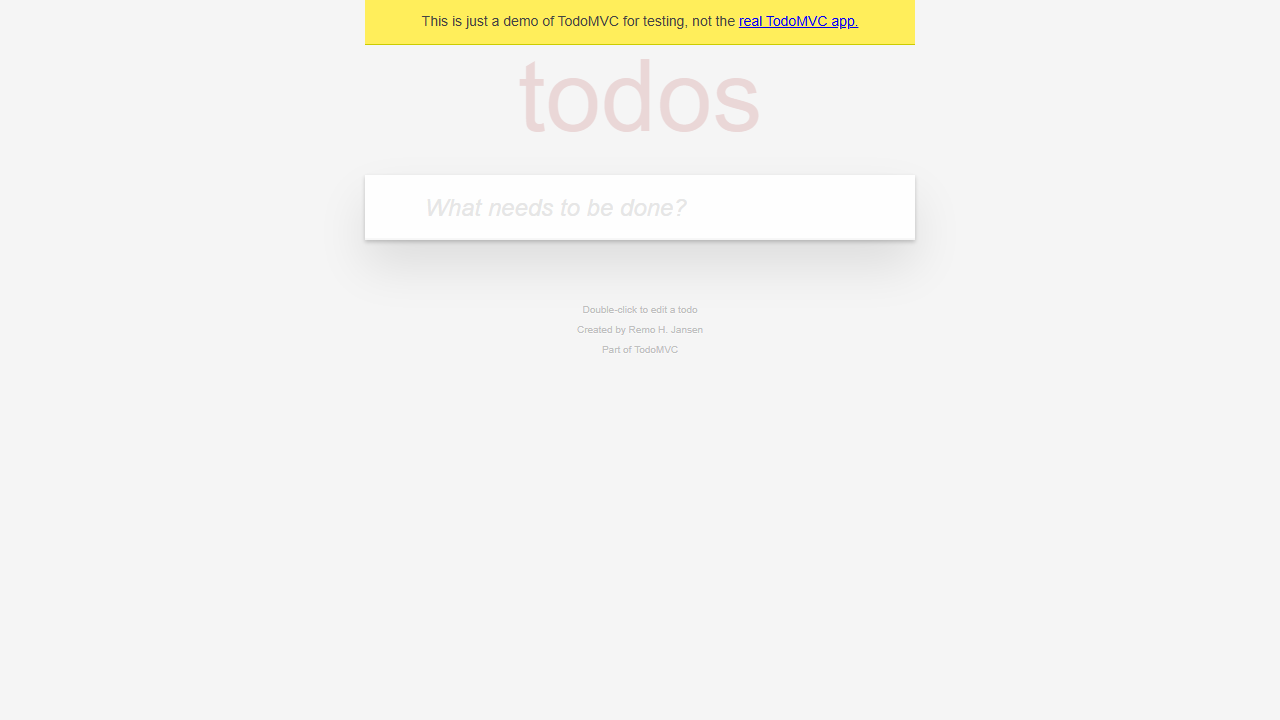

📸 4 tareas creadas


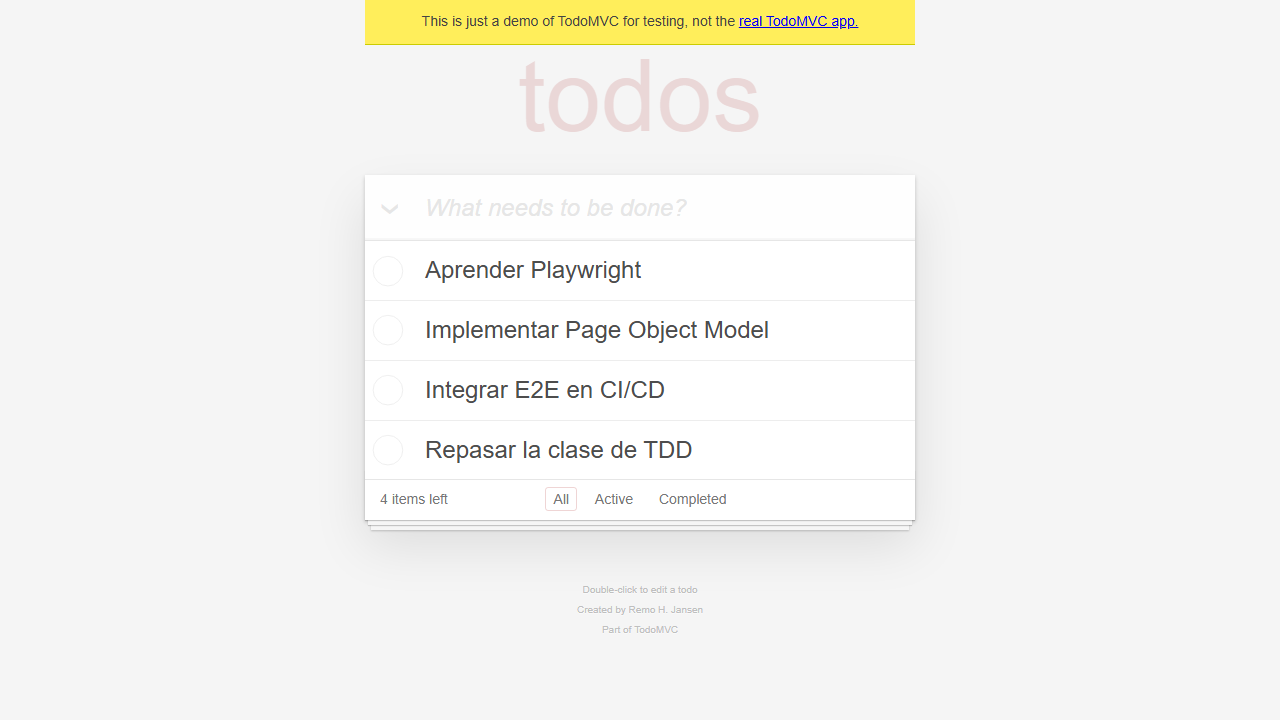

Pendientes: 4
📸 2 tareas completadas


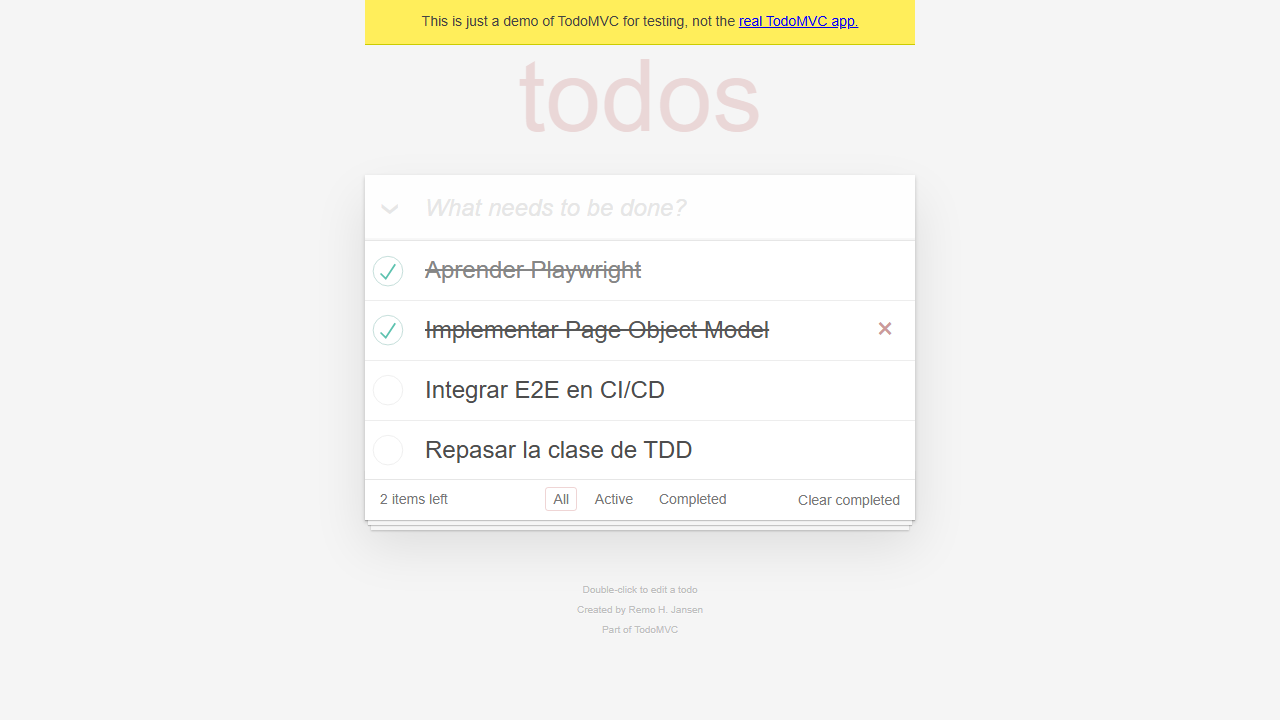

Pendientes despues de completar 2: 2
📸 Filtro: solo activas (2)


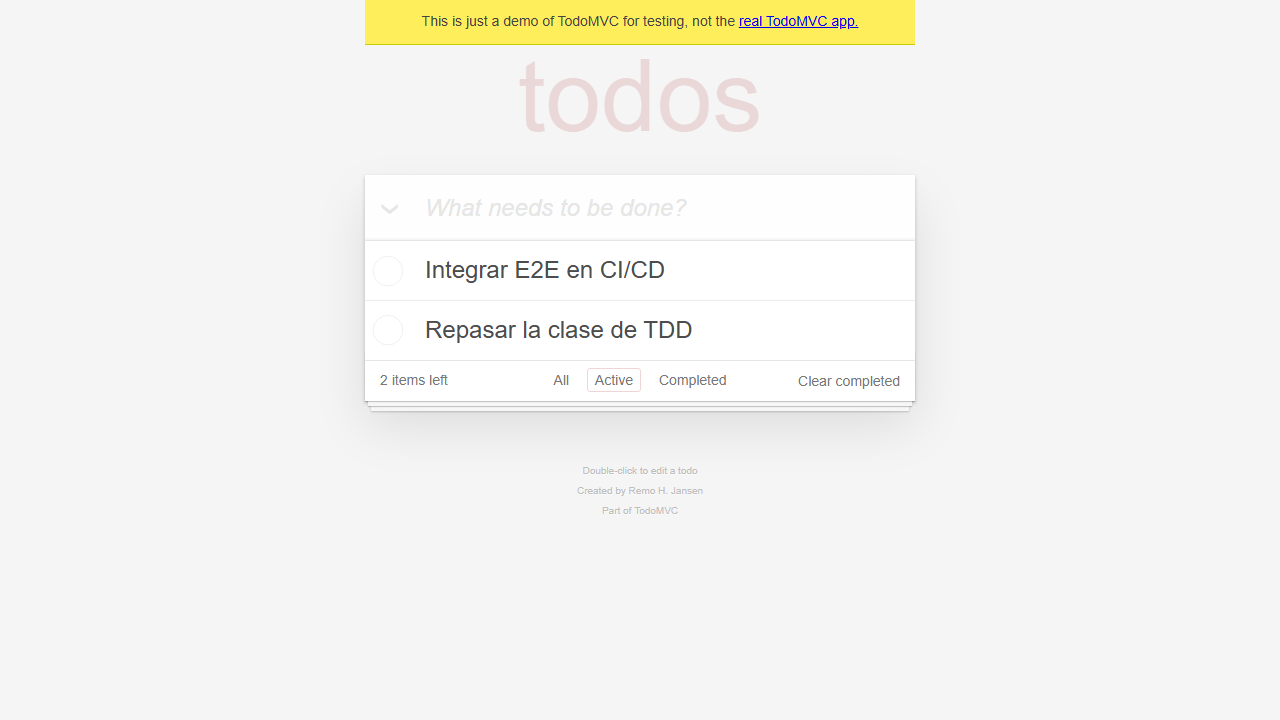

📸 Filtro: solo completadas (2)


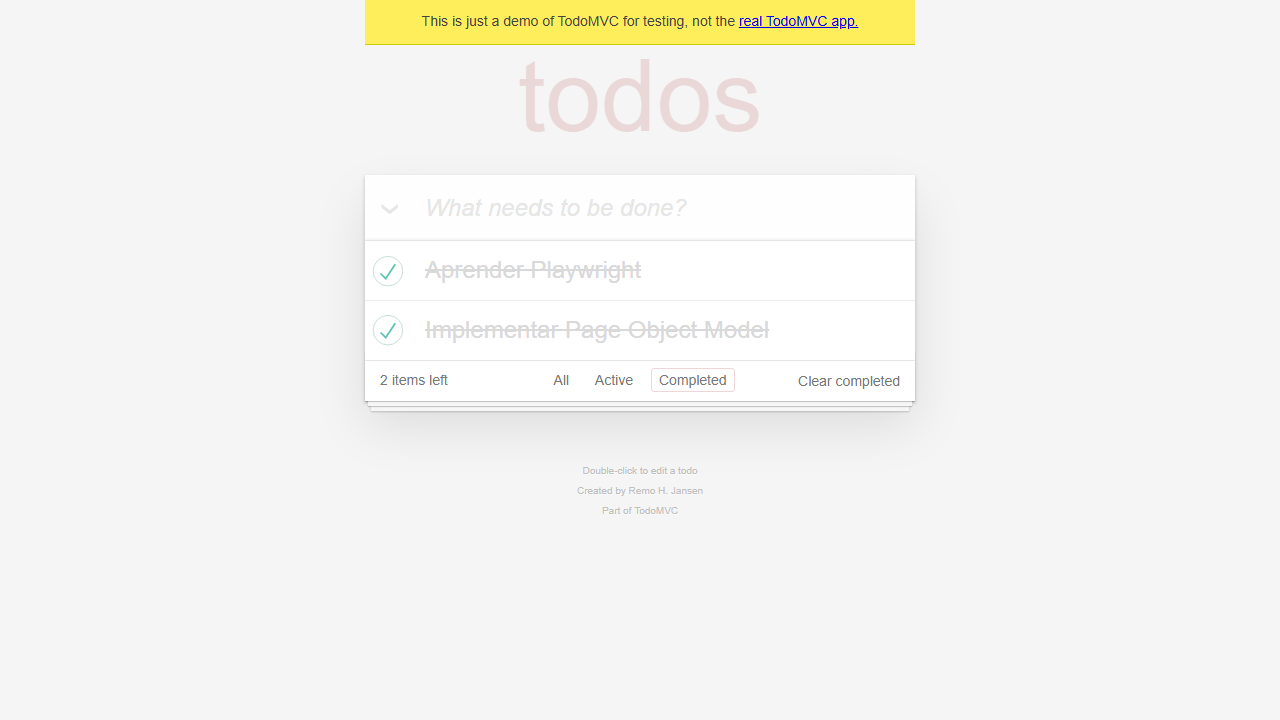

📸 Completadas eliminadas - quedan 2


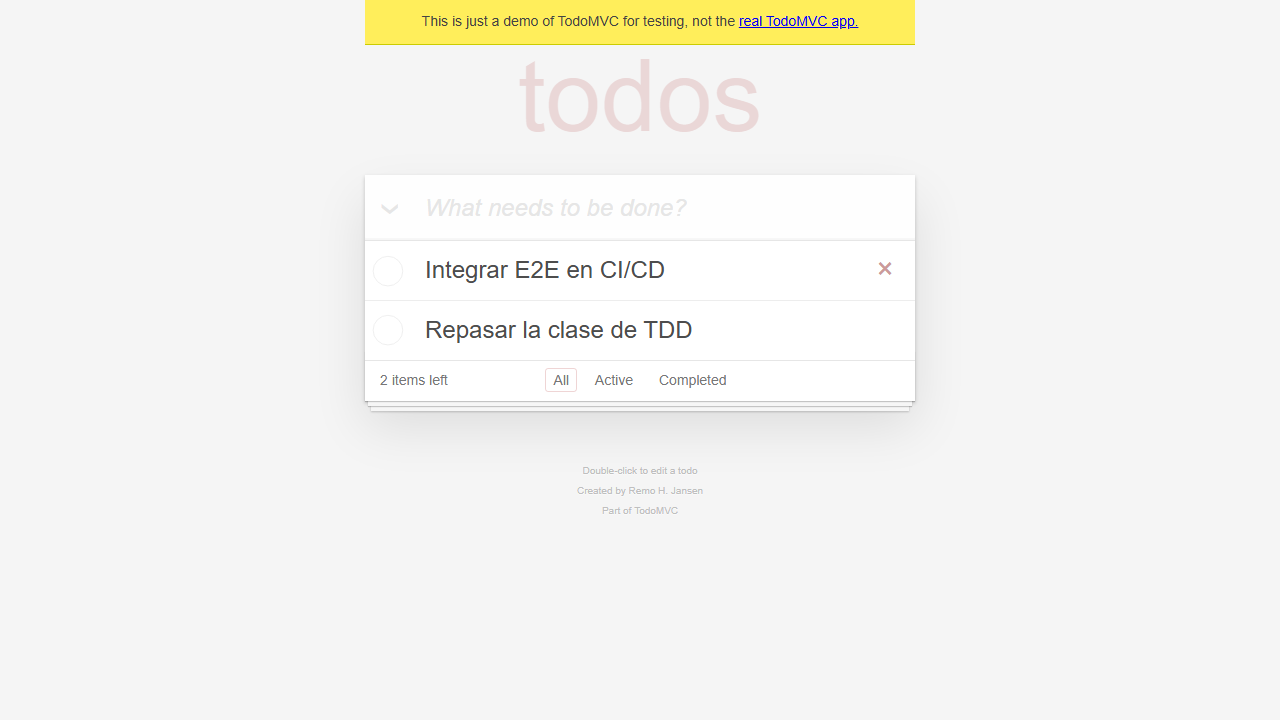

Items despues de limpiar: 2

✅ Flujo completo con POM - todos los assertions pasaron


In [7]:
# -- Demo 3: Flujo completo usando el POM --------------------
# Observa como el test es legible y no contiene selectores

from playwright.sync_api import sync_playwright, expect

def run_demo3():
    with sync_playwright() as pw:
        browser = pw.chromium.launch(headless=True)
        page = browser.new_page()
        todo = TodoPage(page)

        # Asegurar un estado limpio para esta demo
        page.goto(TODO_URL)
        page.evaluate("localStorage.clear();")
        page.reload()

        # -- ARRANQUE ----------------------------------------
        todo.navigate()
        screenshot(page, 'pom_inicio', 'App vacia al inicio')

        # -- CREAR TAREAS ------------------------------------
        todo.agregar_tareas([
            'Aprender Playwright',
            'Implementar Page Object Model',
            'Integrar E2E en CI/CD',
            'Repasar la clase de TDD',
        ])

        expect(todo.items).to_have_count(4)
        expect(todo.contador_texto).to_have_text('4 items left')
        screenshot(page, 'pom_4tareas', '4 tareas creadas')
        print(f'Pendientes: {todo.get_conteo_pendientes()}')

        # -- COMPLETAR ALGUNAS -------------------------------
        todo.completar_tarea('Aprender Playwright')
        todo.completar_tarea('Implementar Page Object Model')

        expect(todo.contador_texto).to_have_text('2 items left')
        screenshot(page, 'pom_completadas', '2 tareas completadas')
        print(f'Pendientes despues de completar 2: {todo.get_conteo_pendientes()}')

        # -- FILTROS -----------------------------------------
        todo.filtrar_activas()
        expect(todo.items).to_have_count(2)
        screenshot(page, 'pom_activas', 'Filtro: solo activas (2)')

        todo.filtrar_completadas()
        expect(todo.items).to_have_count(2)
        screenshot(page, 'pom_completadas_filtro', 'Filtro: solo completadas (2)')

        # -- LIMPIAR COMPLETADAS -----------------------------
        todo.limpiar_completadas()
        todo.filtrar_todas()
        expect(todo.items).to_have_count(2)
        screenshot(page, 'pom_limpio', 'Completadas eliminadas - quedan 2')
        print(f'Items despues de limpiar: {todo.get_conteo_items()}')

        browser.close()
        print('\n✅ Flujo completo con POM - todos los assertions pasaron')

run_in_thread(run_demo3)

---

## 🎯 Ejercicio de Cierre — 15 Minutos

### Contexto

Ya tienes la clase `TodoPage` lista. Tu trabajo es escribir **5 funciones de test** que cubran los escenarios indicados. Cada función debe usar `TodoPage` — sin selectores directos en los tests.

### Reglas

- ✅ Usa **solo métodos de `TodoPage`** en los tests (no `page.locator()` directamente)
- ✅ Usa **`expect()`** para las verificaciones (no solo `assert`)
- ✅ Cada test debe ser **independiente** (navega al inicio en cada uno)
- ❌ No uses `time.sleep()` — Playwright maneja los tiempos automáticamente

### Tests a implementar

| # | Nombre del test | Descripción |
|---|-----------------|-------------|
| 1 | `test_app_inicia_vacia` | Al abrir la app, la lista de tareas debe estar vacía |
| 2 | `test_crear_tarea_aparece_en_lista` | Al crear una tarea, debe aparecer visible en la lista |
| 3 | `test_completar_tarea_reduce_contador` | Al completar 1 de 3, el contador baja a 2 |
| 4 | `test_filtro_active_oculta_completadas` | El filtro Active solo muestra las no completadas |
| 5 | `test_limpiar_completadas_las_elimina` | Clear completed elimina solo las completadas |


In [8]:
from playwright.sync_api import sync_playwright, Page, expect

# ====================================
#  EJERCICIO - Completa las funciones de test
#  Ejecuta esta celda cuando termines para ver los resultados
# ====================================

def test_app_inicia_vacia(page: Page):
    """
    DADO:    abro la app por primera vez
    CUANDO:  no he creado ninguna tarea
    ENTONCES: la lista de tareas debe estar vacia (count=0)
    """
    todo = TodoPage(page)
    todo.navigate()

    expect(todo.items).to_have_count(0)


def test_crear_tarea_aparece_en_lista(page: Page):
    """
    DADO:    la app esta vacia
    CUANDO:  creo la tarea 'Estudiar Playwright'
    ENTONCES: esa tarea aparece visible en la lista
    """
    todo = TodoPage(page)
    todo.navigate()

    todo.agregar_tarea('Estudiar Playwright')
    expect(todo.items).to_have_count(1)
    expect(todo.items.filter(has_text='Estudiar Playwright')).to_have_count(1)


def test_completar_tarea_reduce_contador(page: Page):
    """
    DADO:    tengo 3 tareas pendientes
    CUANDO:  completo la primera
    ENTONCES: el contador de pendientes baja a 2
    """
    todo = TodoPage(page)
    todo.navigate()
    todo.agregar_tareas(['Tarea A', 'Tarea B', 'Tarea C'])

    todo.completar_tarea('Tarea A')
    expect(todo.contador).to_have_text('2')


def test_filtro_active_oculta_completadas(page: Page):
    """
    DADO:    tengo 3 tareas y completo 1
    CUANDO:  activo el filtro 'Active'
    ENTONCES: solo se ven 2 tareas (las no completadas)
    """
    todo = TodoPage(page)
    todo.navigate()
    todo.agregar_tareas(['Primera', 'Segunda', 'Tercera'])
    todo.completar_tarea('Primera')

    todo.filtrar_activas()
    expect(todo.items).to_have_count(2)


def test_filtro_completadas_muestra_solo_completadas(page: Page):
    """
    DADO:    tengo 3 tareas y 2 estan completadas
    CUANDO:  activo el filtro 'Completed'
    ENTONCES: solo se ven 2 tareas (las completadas)
    """
    todo = TodoPage(page)
    todo.navigate()
    todo.agregar_tareas(['Activa 1', 'Completada 1', 'Activa 2', 'Completada 2'])
    todo.completar_tarea('Completada 1')
    todo.completar_tarea('Completada 2')

    todo.filtrar_completadas()
    expect(todo.items).to_have_count(2)


def test_limpiar_completadas_las_elimina(page: Page):
    """
    DADO:    tengo 3 tareas y 2 estan completadas
    CUANDO:  hago clic en 'Clear completed'
    ENTONCES: quedan exactamente 1 tarea (la no completada)
    """
    todo = TodoPage(page)
    todo.navigate()
    todo.agregar_tareas(['Keep me', 'Delete me 1', 'Delete me 2'])

    todo.completar_tarea('Delete me 1')
    todo.completar_tarea('Delete me 2')
    todo.limpiar_completadas()
    todo.filtrar_todas()
    expect(todo.items).to_have_count(1)


# Define todos_los_tests BEFORE run_all_tests is defined
todos_los_tests = [
    test_app_inicia_vacia,
    test_crear_tarea_aparece_en_lista,
    test_completar_tarea_reduce_contador,
    test_filtro_active_oculta_completadas,
    test_filtro_completadas_muestra_solo_completadas,
    test_limpiar_completadas_las_elimina,
]

def run_all_tests():
    resultados = []

    with sync_playwright() as pw:
        browser = pw.chromium.launch(headless=True)

        for fn in todos_los_tests:
            page = browser.new_page()
            nombre = fn.__name__
            try:
                # Estado limpio antes de cada test
                page.goto(TODO_URL)
                page.evaluate("localStorage.clear();")
                page.reload()

                fn(page)
                resultados.append((nombre, 'PASS', None))
            except Exception as e:
                resultados.append((nombre, 'FAIL', str(e)[:120]))
                page.screenshot(path=f'/tmp/fail_{nombre}.png')
            finally:
                page.close()

        browser.close()

    # Reporte
    print('\n' + '=' * 60)
    print('  RESULTADOS DE LOS TESTS')
    print('=' * 60)
    passed = sum(1 for _, s, _ in resultados if 'PASS' in s)
    for nombre, status, error in resultados:
        print(f'  {status}  {nombre}')
        if error:
            print(f'         -> {error}')
    print('=' * 60)
    print(f'  {passed}/{len(resultados)} tests pasaron')
    print('=' * 60)

    if passed == len(resultados):
        print('\n-> Todos los tests pasan. Excelente trabajo.')
    else:
        print(f'\n-> {len(resultados)-passed} test(s) pendientes. Sigue adelante.')

run_in_thread(run_all_tests)

C:\Users\WinterOS\AppData\Local\Temp\ipykernel_21144\2512270375.py:20: DeprecationWarning: 'asyncio.WindowsProactorEventLoopPolicy' is deprecated and slated for removal in Python 3.16
  if sys.platform == 'win32' and hasattr(asyncio, 'WindowsProactorEventLoopPolicy'):



  RESULTADOS DE LOS TESTS
  PASS  test_app_inicia_vacia
  PASS  test_crear_tarea_aparece_en_lista
  PASS  test_completar_tarea_reduce_contador
  PASS  test_filtro_active_oculta_completadas
  PASS  test_filtro_completadas_muestra_solo_completadas
  PASS  test_limpiar_completadas_las_elimina
  6/6 tests pasaron

-> Todos los tests pasan. Excelente trabajo.


---
## ✅ Solución Completa

> **No mirar hasta haber intentado el ejercicio.** 🙈

C:\Users\WinterOS\AppData\Local\Temp\ipykernel_21144\2512270375.py:20: DeprecationWarning: 'asyncio.WindowsProactorEventLoopPolicy' is deprecated and slated for removal in Python 3.16
  if sys.platform == 'win32' and hasattr(asyncio, 'WindowsProactorEventLoopPolicy'):



  SOLUCION - RESULTADOS FINALES
  PASS  test_app_inicia_vacia
  PASS  test_crear_tarea_aparece_en_lista
  PASS  test_completar_tarea_reduce_contador
  PASS  test_filtro_active_oculta_completadas
  PASS  test_filtro_completadas_muestra_solo_completadas
  PASS  test_limpiar_completadas_las_elimina
  6/6 tests pasaron

Estados finales de cada test:

  -> test_app_inicia_vacia


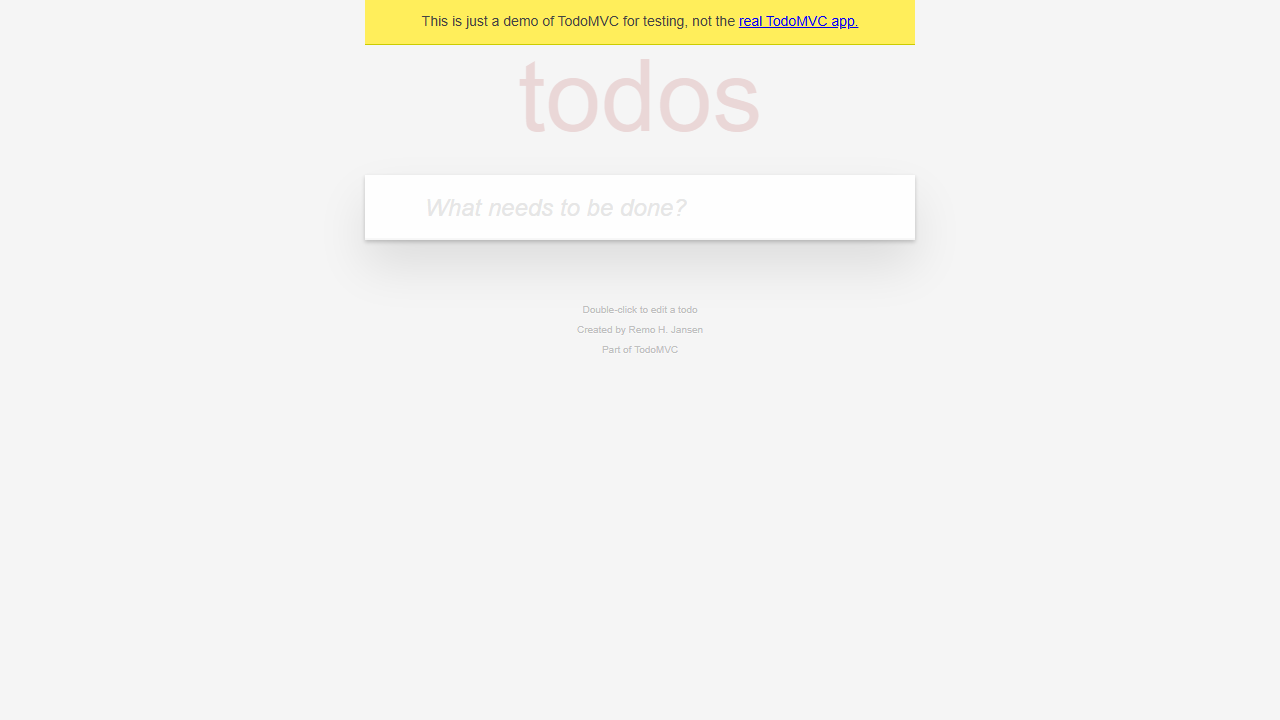


  -> test_crear_tarea_aparece_en_lista


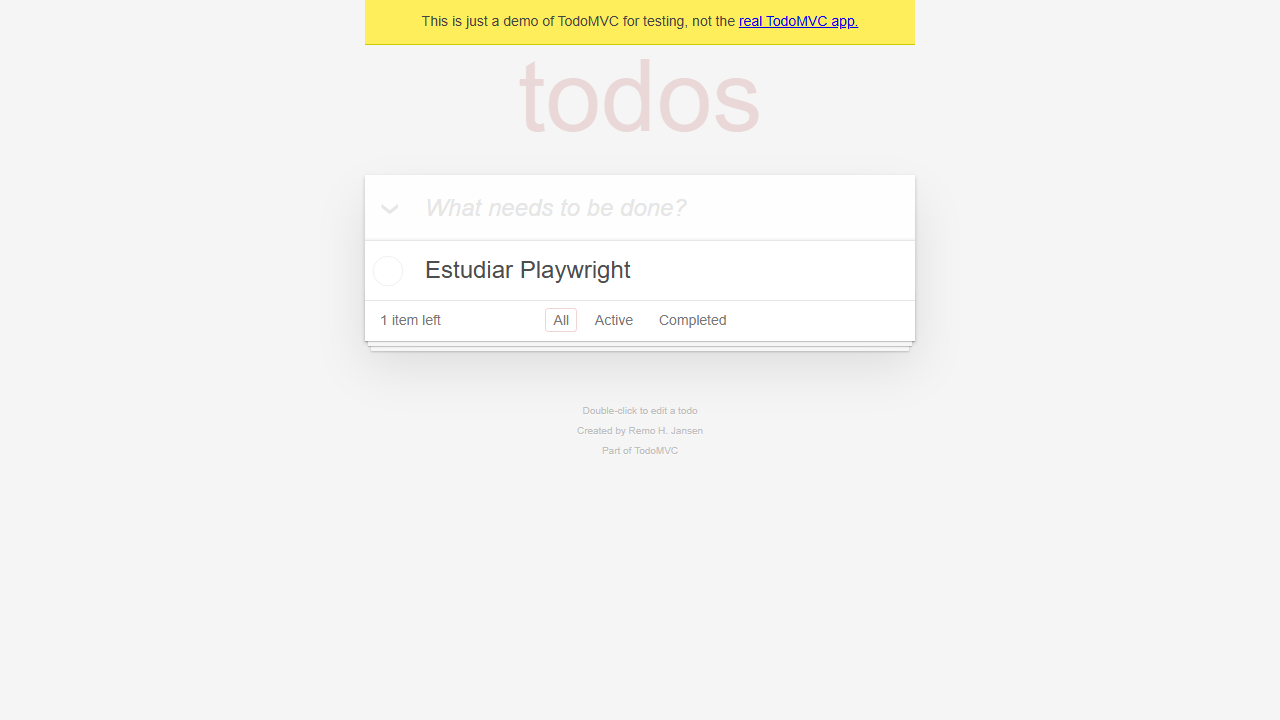


  -> test_completar_tarea_reduce_contador


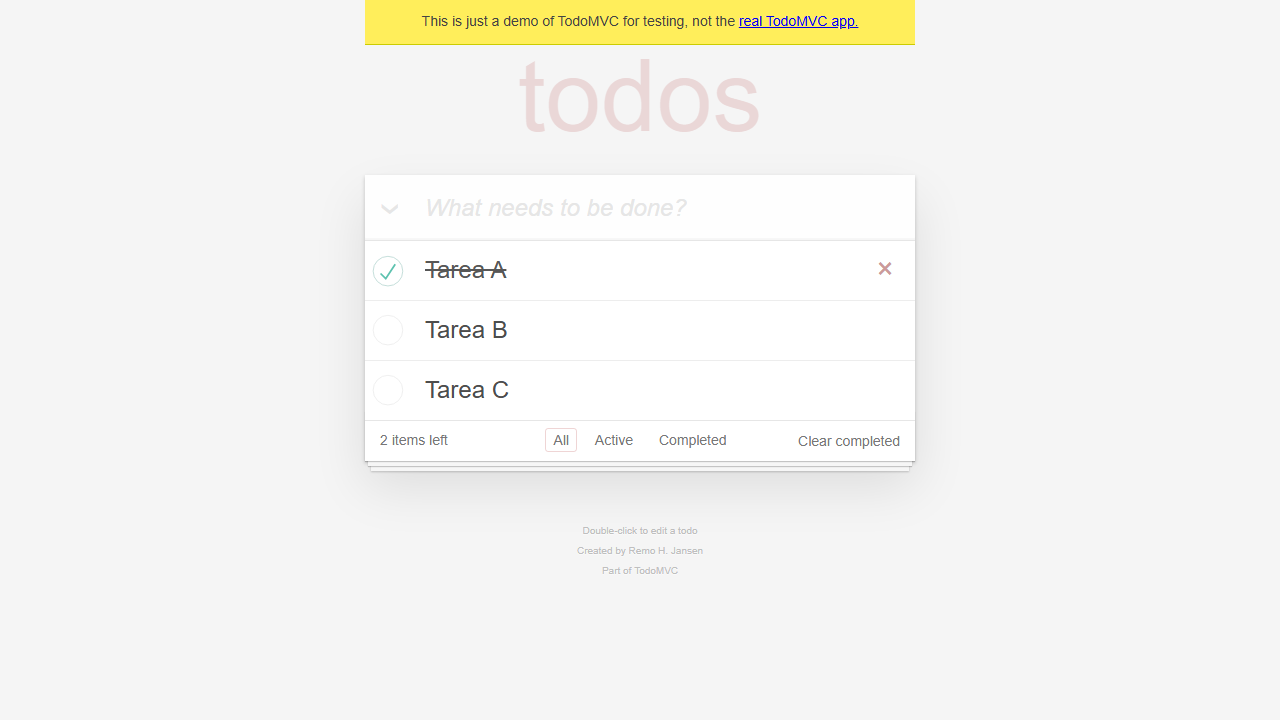


  -> test_filtro_active_oculta_completadas


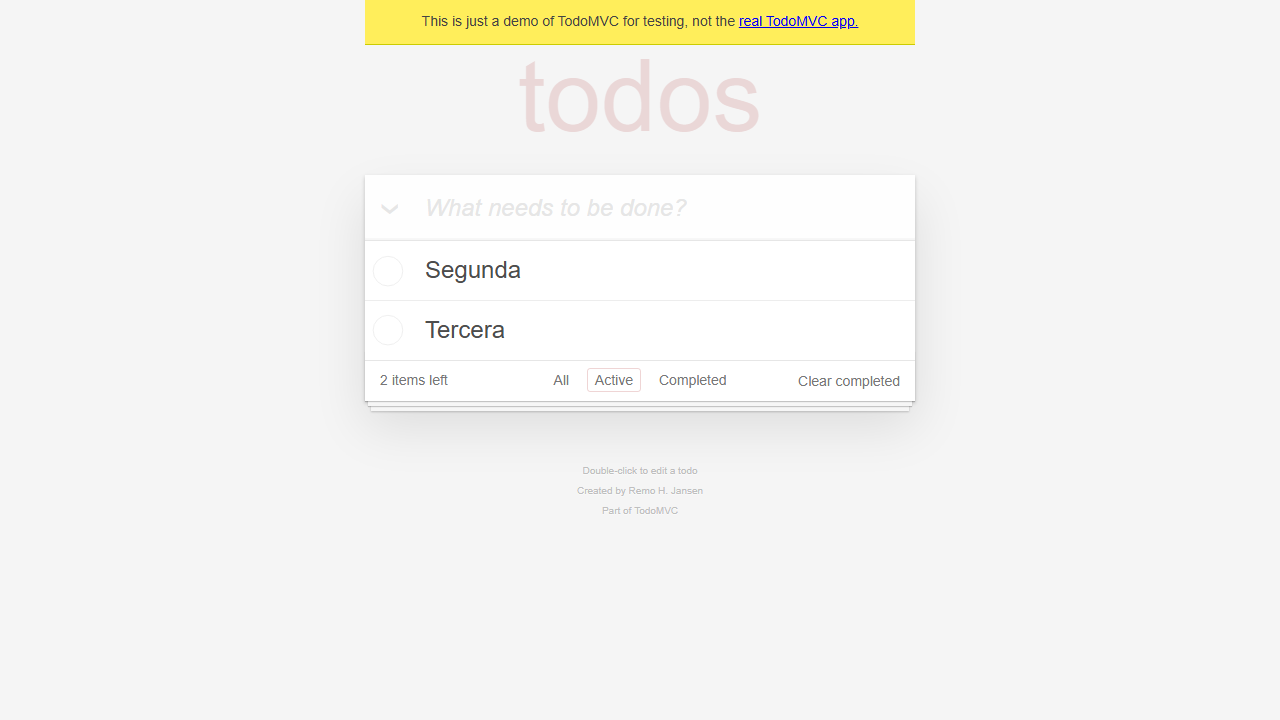


  -> test_filtro_completadas_muestra_solo_completadas


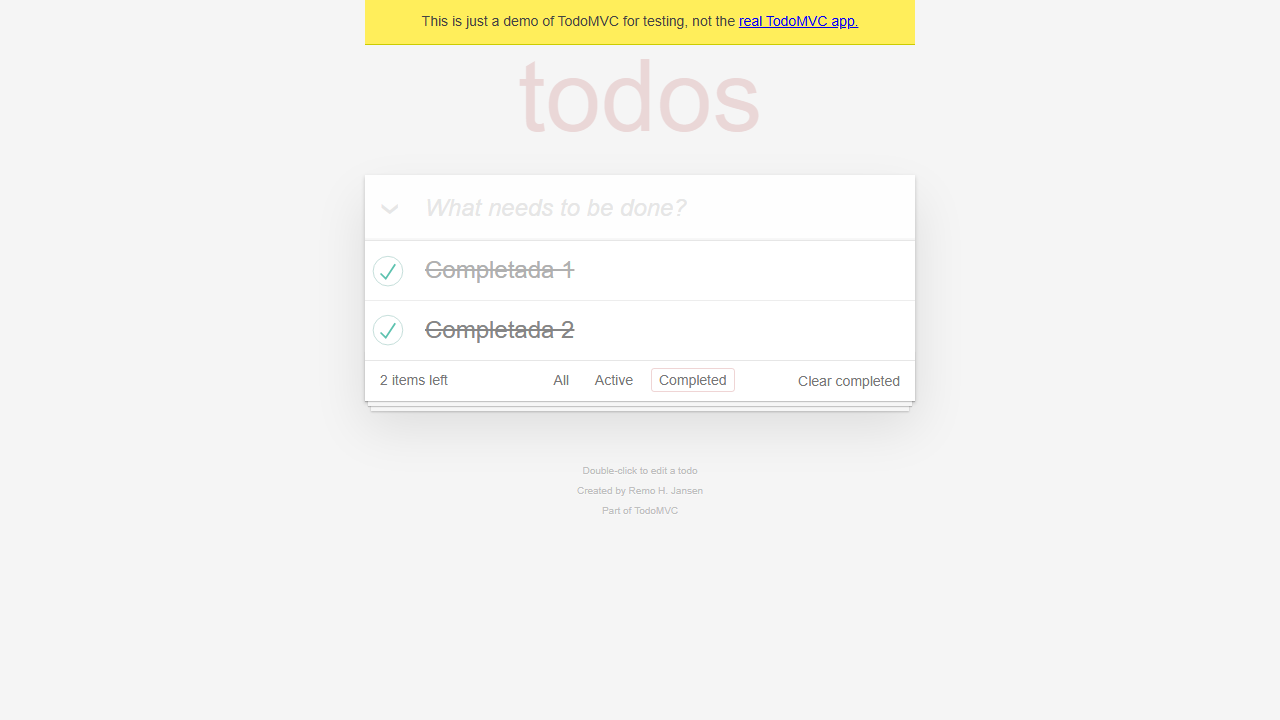


  -> test_limpiar_completadas_las_elimina


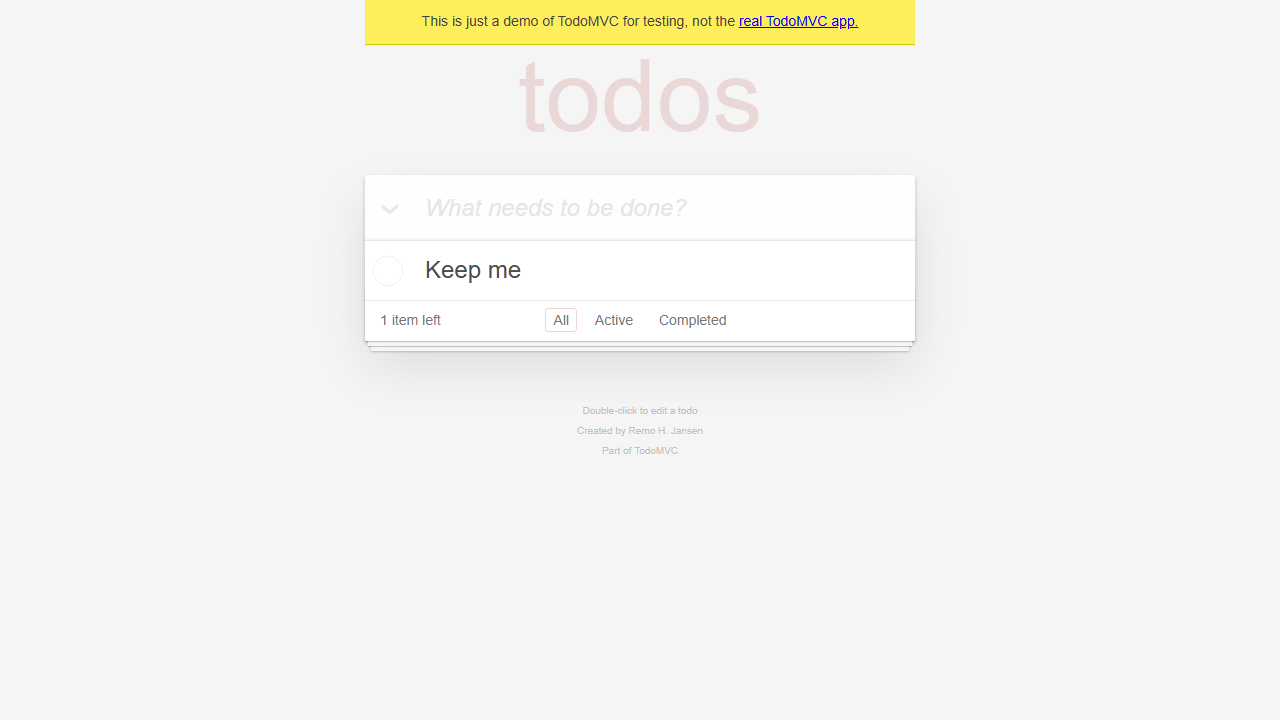

In [9]:
from playwright.sync_api import sync_playwright, Page, expect

# ====================================
#  SOLUCION - 5 tests implementados
# ====================================

def test_app_inicia_vacia(page: Page):
    todo = TodoPage(page)
    todo.navigate()
    expect(todo.items).to_have_count(0)


def test_crear_tarea_aparece_en_lista(page: Page):
    todo = TodoPage(page)
    todo.navigate()
    todo.agregar_tarea('Estudiar Playwright')
    expect(todo.items).to_have_count(1)
    expect(page.get_by_text('Estudiar Playwright')).to_be_visible()


def test_completar_tarea_reduce_contador(page: Page):
    todo = TodoPage(page)
    todo.navigate()
    todo.agregar_tareas(['Tarea A', 'Tarea B', 'Tarea C'])
    todo.completar_tarea('Tarea A')
    expect(todo.contador).to_have_text('2')


def test_filtro_active_oculta_completadas(page: Page):
    todo = TodoPage(page)
    todo.navigate()
    todo.agregar_tareas(['Primera', 'Segunda', 'Tercera'])
    todo.completar_tarea('Primera')
    todo.filtrar_activas()
    expect(todo.items).to_have_count(2)
    expect(page.get_by_text('Primera')).not_to_be_visible()


def test_filtro_completadas_muestra_solo_completadas(page: Page):
    todo = TodoPage(page)
    todo.navigate()
    todo.agregar_tareas(['Activa 1', 'Completada 1', 'Activa 2', 'Completada 2'])
    todo.completar_tarea('Completada 1')
    todo.completar_tarea('Completada 2')

    todo.filtrar_completadas()

    expect(todo.items).to_have_count(2)
    expect(page.get_by_text('Completada 1')).to_be_visible()
    expect(page.get_by_text('Completada 2')).to_be_visible()
    expect(page.get_by_text('Activa 1')).not_to_be_visible()
    expect(page.get_by_text('Activa 2')).not_to_be_visible()


def test_limpiar_completadas_las_elimina(page: Page):
    todo = TodoPage(page)
    todo.navigate()
    todo.agregar_tareas(['Keep me', 'Delete me 1', 'Delete me 2'])

    todo.completar_tarea('Delete me 1')
    todo.completar_tarea('Delete me 2')
    todo.limpiar_completadas()
    todo.filtrar_todas()
    expect(todo.items).to_have_count(1)
    expect(page.get_by_text('Keep me')).to_be_visible()


# -- Runner --------------------------------------------------
todos_los_tests = [
    test_app_inicia_vacia,
    test_crear_tarea_aparece_en_lista,
    test_completar_tarea_reduce_contador,
    test_filtro_active_oculta_completadas,
    test_filtro_completadas_muestra_solo_completadas,
    test_limpiar_completadas_las_elimina,
]

resultados = []
screenshots_finales = []

def run_solution_tests():
    with sync_playwright() as pw:
        browser = pw.chromium.launch(headless=True)

        for fn in todos_los_tests:
            page = browser.new_page()
            nombre = fn.__name__
            try:
                page.goto(TODO_URL)
                page.evaluate("localStorage.clear();")
                page.reload()

                fn(page)
                path = f'/tmp/sol_{nombre}.png'
                page.screenshot(path=path)
                screenshots_finales.append((path, nombre))
                resultados.append((nombre, 'PASS', None))
            except Exception as e:
                resultados.append((nombre, 'FAIL', str(e)[:150]))
            finally:
                page.close()

        browser.close()

run_in_thread(run_solution_tests)

# Reporte
print('\n' + '=' * 60)
print('  SOLUCION - RESULTADOS FINALES')
print('=' * 60)
for nombre, status, error in resultados:
    print(f'  {status}  {nombre}')
    if error:
        print(f'         -> {error}')
print('=' * 60)
print(f'  {sum(1 for _, s, _ in resultados if "PASS" in s)}/{len(resultados)} tests pasaron')
print('=' * 60)

# Mostrar screenshots de cada test
print('\nEstados finales de cada test:')
for path, nombre in screenshots_finales:
    print(f'\n  -> {nombre}')
    display(Image(path, width=500))

---

## 📊 Resumen de lo aprendido

| Concepto | Lo que vimos |
|----------|--------------|
| `sync_playwright()` | Contexto para crear el browser y las páginas |
| `page.goto(url)` | Navegar a una URL |
| `get_by_role()`, `get_by_placeholder()` | Locators robustos y semánticos |
| `expect(...).to_have_count()` | Aserciones con auto-retry |
| `fill()`, `press()`, `click()`, `check()` | Acciones sobre elementos |
| `Page Object Model` | Clase que encapsula selectores y acciones |
| Tests independientes | Cada test navega desde cero, sin depender de otro |

---

* Pruebas de Software · 7mo Semestre*